In [1]:
import math
angmin,angmax = -0.314831, 0.039103
dermin,dermax = angmin*180/math.pi, angmax*180/math.pi
dermin,dermax

(-18.038487559883222, 2.240436866300058)

In [2]:
from laserscan import SemLaserScanWaymo
scan = SemLaserScanWaymo(sem_color_dict=None, project=False, H=64, W=2650, fov_up=2.25, fov_down=-18.1, 
    max_classes=24,DA=False,flip_sign=False,drop_points=False)

In [3]:
scan.open_scan('/ari/users/ibaskaya/Downloads/datasets/waymo/waymodataset/training/images/10017090168044687777_6380_000_6400_000_000.npz')

In [4]:
scan.points.shape

(154450, 3)

In [5]:
scan.remissions.shape

(154450,)

In [6]:
scan.open_label('/ari/users/ibaskaya/Downloads/datasets/waymo/waymodataset/training/labels/10017090168044687777_6380_000_6400_000_000.npz')

In [7]:
scan.sem_label.shape

(154450,)

In [8]:
type({i:i for i in range(23)})

dict

In [9]:
import sys
sys.path.append('/ari/users/ibaskaya/projeler/SalsaNext/train/tasks/semantic/dataset/kitti')
sys.path.append('/ari/users/ibaskaya/projeler/kittisalsa/utils')
sys.path.append('/ari/users/ibaskaya/projeler/SalsaNext/train')
from parser import SemanticKitti
from mappings import kitti, kitticolormap,sem2sem, kitti_lm_inv,waymocolormap,waymo
sensor={
    'name': "HDL64",
    'type': "spherical" ,
    'fov_up': 3,
    'fov_down': -25,
    'img_prop': {
      'width': 2048,
      'height': 64},
    'img_means':[ #range,x,y,z,signal
       12.12,
       10.88,
       0.23,
       -1.04,
       0.21],
    'img_stds':[ #range,x,y,z,signal
       12.32,
       11.47,
       6.91,
       0.86,
       0.16]
}

Sequences folder exists! Using sequences from /ari/users/ibaskaya/Downloads/datasets/semantickitti_small/sequences
parsing seq 00
parsing seq 01
parsing seq 02
parsing seq 03
Using 64 scans from sequences [0, 1, 2, 3]
tensor(2.6959)


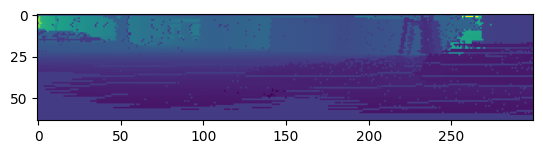

In [10]:
root = '/ari/users/ibaskaya/Downloads/datasets/waymo/waymodataset'
root = '/ari/users/ibaskaya/Downloads/datasets/semantickitti_small'
sequences = [0,1,2,3]
labels = kitti
color_map = kitticolormap
learning_map = sem2sem
learning_map_inv = kitti_lm_inv
sensor = sensor 
max_points=150000
gt=True
transform=False
iswaymo = False
istrain = False
ds = SemanticKitti(root,    # directory where data is
               sequences,     # sequences for this data (e.g. [1,3,4,6])
               labels,        # label dict: (e.g 10: "car")
               color_map,     # colors dict bgr (e.g 10: [255, 0, 0])
               learning_map,  # classes to learn (0 to N-1 for xentropy)
               learning_map_inv,    # inverse of previous (recover labels)
               sensor,              # sensor to parse scans from
               max_points=150000,   # max number of points present in dataset
               gt=True,             # send ground truth?
               transform=False,
               iswaymo = False,
               istrain = False)

b = next(iter(ds))
import matplotlib.pyplot as plt
plt.imshow(b[0][0][...,100:400])
rim = b[0][0]
print((rim!=0).sum()/(rim==0).sum())

Sequences folder exists! Using sequences from /ari/users/ibaskaya/Downloads/datasets/waymo/waymodataset/training
Using 23691 scans from sequences [0, 1, 2, 3]
tensor(0.5030)


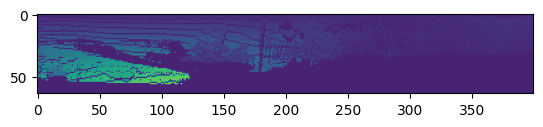

In [15]:
root = '/ari/users/ibaskaya/Downloads/datasets/waymo/waymodataset'
sequences = [0,1,2,3]
labels = waymo
color_map = waymocolormap
learning_map = {i:i for i in range(23)}
learning_map_inv = {i:i for i in range(23)}
sensor = sensor 
max_points=170000
gt=True
transform=False
iswaymo = True
istrain = True
sensor={
    'name': "HDL64",
    'type': "spherical" ,
    'fov_up': 18,
    'fov_down': -18,
    'img_prop': {
      'width': 2650,
      'height': 64},
    'img_means':[ #range,x,y,z,signal
       12.12,
       10.88,
       0.23,
       -1.04,
       0.21],
    'img_stds':[ #range,x,y,z,signal
       12.32,
       11.47,
       6.91,
       0.86,
       0.16]
}
ds = SemanticKitti(root,    # directory where data is
               sequences,     # sequences for this data (e.g. [1,3,4,6])
               labels,        # label dict: (e.g 10: "car")
               color_map,     # colors dict bgr (e.g 10: [255, 0, 0])
               learning_map,  # classes to learn (0 to N-1 for xentropy)
               learning_map_inv,    # inverse of previous (recover labels)
               sensor,              # sensor to parse scans from
               max_points=max_points,   # max number of points present in dataset
               gt=gt,             # send ground truth?
               transform=transform,
               iswaymo = iswaymo,
               istrain = istrain)

b = next(iter(ds))
import matplotlib.pyplot as plt
plt.imshow(b[0][0][...,0:400])
rim = b[0][0]
print((rim!=0).sum()/(rim==0).sum())

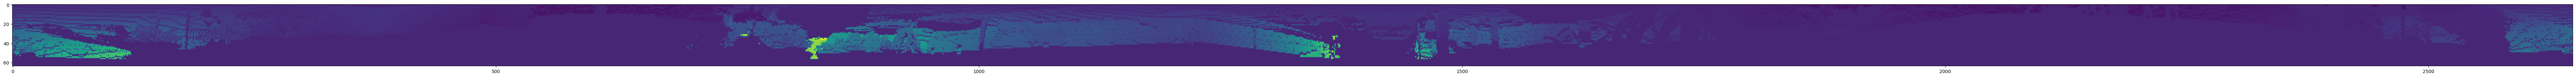

In [16]:
plt.figure(figsize=(100, 25))

# Display the image
plt.imshow(b[0][0][...,:])

# Show the plot
plt.show()

In [13]:
import numpy as np
ar = np.load(ds.scan_files[0])['array']

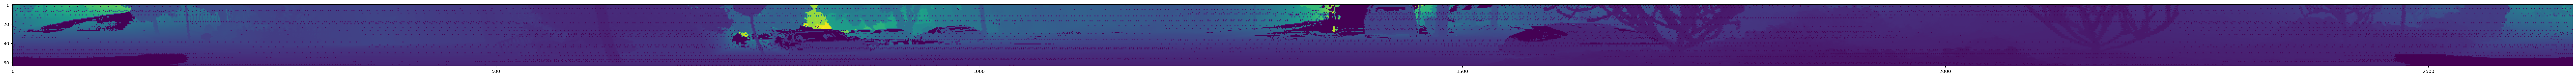

In [14]:
plt.figure(figsize=(100, 25))
plt.imshow(ar[0][...,:])
plt.show()